In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch
import model_definition as m
import utils as u
import torch.nn.functional as F
import copy
from torch.utils.data import DataLoader, random_split
import os

(128, 128, 285)


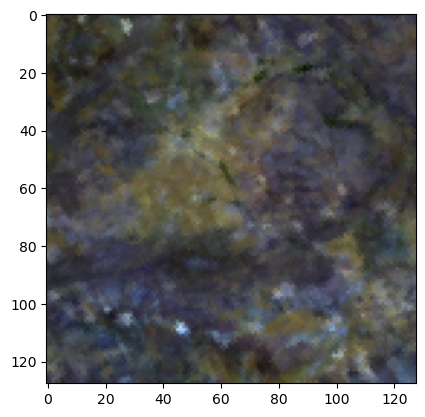

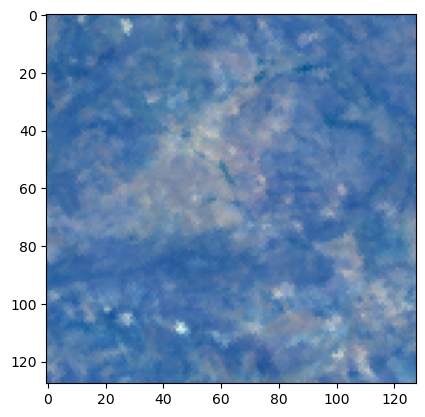

In [2]:
h5_file = h5py.File('/new_emit_dataset_vol/just_hypercubes/20230403T111207/chip_0.h5', 'r')
h5_array = np.array(h5_file['hypercube'], dtype=np.float32)
print(h5_array.shape)

#normalize chip:
h5_array, chip_mean, chip_std = u.normalize_chip(h5_array)
u.visualize_hypercube(h5_array)
u.visualize_hypercube(u.unnormalize_chip(h5_array, chip_mean, chip_std))

In [ ]:
# Training Setup:
num_epochs = 240
report_every = 4
vis_every = 40
batch_size = 64

learning_rate_schedule = [0.001, 0.0003, 0.0003, 0.0001]  #Model shows instability at 0.003, 0.001 seems safe
learning_rate_schedule_step = 60

masking_ratio = 0.75  #if masking ration is 0, must use mse loss instead of masked loss
num_restarts = 3
restart_epochs = 3
restart_lr = learning_rate_schedule[0]

# Model Setup:
device = torch.device("cuda")
model = m.SimpleHyperspectralMAEEncoder(masking_ratio=masking_ratio).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate_schedule[0], weight_decay=0.05)

model_dir = "./models"
load_weights_path = None #model_dir + "/best_model.pth"
save_weights_path = model_dir + "/best_model.pth"

if not os.path.exists(model_dir):
    os.makedirs(model_dir)

if load_weights_path is not None:
    model.load_state_dict(torch.load(load_weights_path))


# chip = torch.from_numpy(h5_array).unsqueeze(0).to(device)
# overfit_batch = chip.repeat(batch_size, 1, 1, 1)

#Dataset:
data_dir = "/root/emit_data/*"
#data_dir = "/root/emit_data/20230107T082416"
full_dataset = u.HyperspectralDataset(data_dir)#, max_files=64)

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [0.8, 0.1, 0.1])

train_dataloader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    num_workers=4,     # Adjust based on your CPU cores
    pin_memory=True    # Speeds up CPU to GPU transfers
)

val_dataloader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=4,
)

test_dataloader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=4,
)


/opt/conda/lib/python3.11/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Dataset initialized with 2296 files.


/opt/conda/lib/python3.11/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Restart 0, Final Loss: 1.0017
Restart 1, Final Loss: 1.0018
Restart 2, Final Loss: 1.0018
Best Restart: 0, Best Loss: 1.0017
Learning Rate: 0.001
Epoch 4, Loss: 1.0251
Epoch 8, Loss: 1.0035
Epoch 12, Loss: 0.9654
Epoch 16, Loss: 0.8071
Epoch 20, Loss: 0.8452
Epoch 24, Loss: 0.4889
Epoch 28, Loss: 0.3912
Epoch 32, Loss: 0.3639
Epoch 36, Loss: 0.3201
Epoch 40, Loss: 0.3028


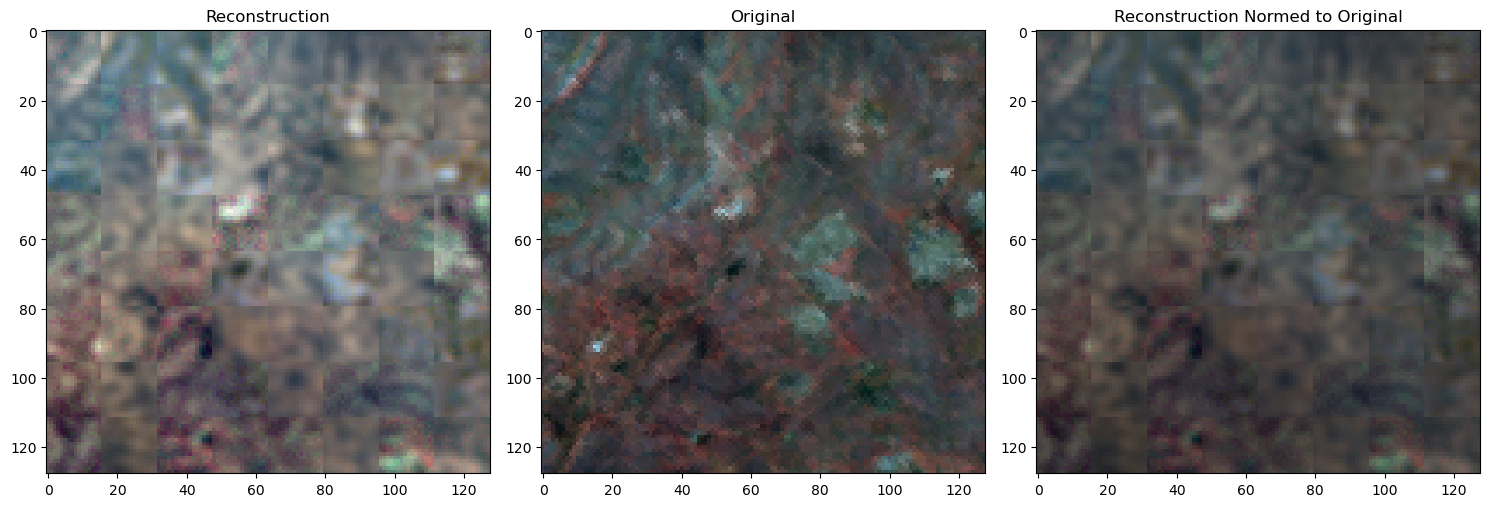

Epoch 44, Loss: 0.2855
Epoch 48, Loss: 0.2703
Epoch 52, Loss: 0.2651


In [ ]:
# Overfit single chip:

scaler = torch.amp.GradScaler()  #Auomatically changes precision where safe to do so

#Random Restarts first:
best_loss = float("inf")
best_state = None
best_restart = -1

for restart in range(num_restarts):
    print(f"Starting Restart {restart+1} of {num_restarts}")
    torch.manual_seed(restart)
    trial_model = m.SimpleHyperspectralMAEEncoder(masking_ratio=masking_ratio).to(device)
    trial_optimizer = torch.optim.AdamW(trial_model.parameters(), lr=restart_lr, weight_decay=0.05)    
    
    trial_model.train()
    for epoch in range(restart_epochs):
        epoch_loss = 0.0
        
        for batch in train_dataloader:
            batch = batch.to(device)
            # 1. Zero Gradients before forward/backward pass:
            trial_optimizer.zero_grad()
            
            # 2. Forward Pass:
            with torch.autocast(device_type='cuda'):
                pred, mask, patches = trial_model(batch)
                loss = trial_model.masked_loss(pred, mask, patches)
            
            # 3. Backward Pass:
            scaler.scale(loss).backward()
            scaler.step(trial_optimizer)
            scaler.update()
            
            epoch_loss += loss.item()
        epoch_loss = epoch_loss / len(train_dataloader)
        print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")
    
    #calculate validation loss:
    val_loss = 0.0
    trial_model.eval()
    with torch.no_grad():
        for batch in val_dataloader:
            batch = batch.to(device)
            with torch.autocast(device_type='cuda'):
                pred, mask, patches = trial_model(batch)
                loss = trial_model.masked_loss(pred, mask, patches)
            val_loss += loss.item()
    val_loss = val_loss / len(val_dataloader)
    
    print(f"Restart {restart}, Final Val Loss: {val_loss:.4f}")
    
    if val_loss < best_loss:
        best_loss = val_loss
        best_state = copy.deepcopy(trial_model.state_dict())
        best_restart = restart
        
print(f"Best Restart: {best_restart}, Best Loss: {best_loss:.4f}")


# Now deep train the best model:
print("Now deep training the best model")

model.load_state_dict(best_state)
model.train()
for i, epoch in enumerate(range(num_epochs)):
    epoch_loss = 0.0
    
    # Learning Rate Updater:
    if i % learning_rate_schedule_step == 0:
        optimizer.param_groups[0]['lr'] = learning_rate_schedule[i // learning_rate_schedule_step]
        print(f"Learning Rate: {optimizer.param_groups[0]['lr']}")
    
    for batch in train_dataloader:
        batch = batch.to(device)
        
        # 1. Zero Gradients before forward/backward pass:
        optimizer.zero_grad()
        
        # 2. Forward Pass:
        with torch.autocast(device_type='cuda'):
            pred, mask, patches = model(batch)
    
            #Loss Calculation:
            #loss = model.mse_loss(pred, patches)
            loss = model.weighted_holistic_loss(pred, mask, patches)
    
        # 3. Backward Pass:
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        epoch_loss += loss.item()
    
    #Report:
    if (epoch + 1) % report_every == 0:
        avg_loss = epoch_loss / len(train_dataloader)
        #calculate validation loss:
        val_loss = 0.0
        model.eval()
        with torch.no_grad():
            for batch in val_dataloader:
                batch = batch.to(device)
                with torch.autocast(device_type='cuda'):
                    pred, mask, patches = model(batch)
                    loss = model.weighted_holistic_loss(pred, mask, patches)
                val_loss += loss.item()
        val_loss = val_loss / len(val_dataloader)
        
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}, Val Loss: {val_loss:.4f}")
        
    #Visualization:
    if (epoch + 1) % vis_every == 0:
        model.eval() # Temporarily put in eval mode
        with torch.no_grad():
            # 1. Grab a single chip properly formatted for the model (1, H, W, C)
            batch = next(iter(test_dataloader))
            single_chip = batch[0].unsqueeze(0) 
            
            # 2. Get predictions
            pred_hwc = model.reconstruct(single_chip)
            
            # 3. Pull data to CPU and numpy, using .detach() safely
            pred_np = pred_hwc[0].detach().cpu().numpy()
            orig_np = single_chip[0].cpu().numpy()
            
            # 4. Visualize
            u.visualize_reconstruction(pred_np, orig_np)
            # plt.show() # Assuming this is handled inside your u.visualize_reconstruction
            
        model.train() # Put back into train mode!
    

In [ ]:
model.eval()
pred_hwc = model.reconstruct(chip)
u.visualize_reconstruction(pred_hwc[0].cpu().numpy(), h5_array)

NameError: name 'chip' is not defined